# Light Reconstruction Demo

Minimal notebook to run the lightweight reconstruction pipeline from `src/privacy/light_reconstruction.py`.

In [1]:
import os
from pathlib import Path

repo_root = Path.cwd()
if not (repo_root / "input").exists():
    for p in repo_root.parents:
        if (p / "input").exists():
            repo_root = p
            break
os.chdir(repo_root)
print("CWD:", os.getcwd())

CWD: /Users/suetake/git-repos/takano_labo/dca


In [2]:
import matplotlib.pyplot as plt

def show_selected(result, method="pinv"):
    labels = result.selected_labels
    n = len(labels)
    fig, axes = plt.subplots(2, n, figsize=(2.2 * n, 4.2))
    if n == 1:
        axes = [[axes[0]], [axes[1]]]
    for i, label in enumerate(labels):
        pair = result.selected_images[method][label]
        orig = pair["original"]
        rec = pair["reconstructed"]
        axes[0][i].imshow(orig, cmap="gray")
        axes[0][i].set_title(f"orig label={label}")
        axes[0][i].axis("off")
        axes[1][i].imshow(rec, cmap="gray")
        axes[1][i].set_title(f"recon ({method})")
        axes[1][i].axis("off")
    plt.tight_layout()
    plt.show()

In [ ]:
from config.config import Config
from src.privacy import run_light_anchor_reconstruction

cfg = Config(
    name="light_recon_demo",
    dataset="mnist",
    y_name="target",
    num_institution_user=1000,
    dim_intermediate=10,
    F_type="svd",
    preprocess=False,
    seed=4,
)

res = run_light_anchor_reconstruction(
    cfg,
    anchor_labels=(0, 1, 2),
    display_labels=(0, 1, 2),
    public_per_label=10,
    num_anchor_data=300,
    methods=("pinv", "mlp", "pinv_not_orth"),
    image_seed_by_label={0: 101, 1: 202, 2: 303},
    evaluate_classifier_accuracy=False,
    reconstruct_anchor_images=False,
)

print("methods:", res.methods)
print("selected_labels:", res.selected_labels)
print("metrics:", res.metrics)

show_selected(res, method="pinv")

cols 785
Index(['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7',
       'pixel8', 'pixel9', 'pixel10'],
      dtype='object')


In [4]:
# Optional: accuracy on selected reconstructed images
res_eval = run_light_anchor_reconstruction(
    cfg,
    anchor_labels=(0, 1, 2),
    display_labels=(0, 1, 2),
    public_per_label=10,
    num_anchor_data=300,
    methods=("pinv", "mlp", "pinv_not_orth"),
    image_seed_by_label={0: 101, 1: 202, 2: 303},
    evaluate_classifier_accuracy=True,
    rf_train_size=5000,
)
res_eval.metrics

cols 785
Index(['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7',
       'pixel8', 'pixel9', 'pixel10'],
      dtype='object')


{'pinv': {'classifier_accuracy': 0.6666666666666666},
 'mlp': {'classifier_accuracy': 0.6666666666666666},
 'pinv_not_orth': {'classifier_accuracy': 0.3333333333333333}}

In [3]:
# Seed sweep: F_type x dim_intermediate for non-leak labels 3..9
import numpy as np
import pandas as pd
import importlib
from sklearn.ensemble import RandomForestClassifier

import src.privacy.light_reconstruction as lr
importlib.reload(lr)
run_light_anchor_reconstruction = lr.run_light_anchor_reconstruction
from config.config import Config
from src.institution_data_pipeline.load_data import load_data

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

f_types = ["svd", "kernel_pca_self_tuning", "umap"]
dim_intermediate_values = [4, 16, 64]
seeds = list(range(1, 11))  # cfg.seed patterns; use range(1, 11) for 10 seeds
methods = ("pinv", "mlp", "pinv_not_orth")

anchor_labels = (0, 1, 2)          # leaked/public anchor labels
eval_labels = (3, 4, 5, 6, 7, 8, 9) # reconstruction/evaluation labels
eval_samples_per_label = 50         # 7 labels x 50 = 350 reconstructed samples per run

# Train the evaluator once and reuse it across all reconstruction runs.
# Keep classifier_labels = None to train a 10-class MNIST evaluator.
classifier_labels = None
shared_rf_train_size = 5000
classifier_cfg = Config(
    name="light_recon_shared_rf",
    dataset="mnist",
    y_name="target",
    preprocess=False,
    seed=0,
)
classifier_df = load_data(classifier_cfg)
classifier_y = classifier_df[classifier_cfg.y_name].to_numpy()
classifier_X = classifier_df.drop(columns=[classifier_cfg.y_name]).to_numpy(dtype=np.float32)
if classifier_labels is not None:
    classifier_mask = np.isin(classifier_y, np.array(classifier_labels))
    classifier_X = classifier_X[classifier_mask]
    classifier_y = classifier_y[classifier_mask]
classifier_rng = np.random.default_rng(0)
classifier_idx = classifier_rng.permutation(len(classifier_X))[: min(shared_rf_train_size, len(classifier_X))]
shared_rf = RandomForestClassifier(random_state=0, n_jobs=-1)
shared_rf.fit(classifier_X[classifier_idx], classifier_y[classifier_idx])

summary_rows = []
error_rows = []
loop_results = {}

grid = [
    (seed, f_type, dim_intermediate)
    for seed in seeds
    for f_type in f_types
    for dim_intermediate in dim_intermediate_values
]

for seed, f_type, dim_intermediate in tqdm(grid, desc="reconstruction seed sweep"):
    cfg_loop = Config(
        name=f"light_recon_seed{seed}_{f_type}_d{dim_intermediate}",
        dataset="mnist",
        y_name="target",
        num_institution_user=1000,
        dim_intermediate=dim_intermediate,
        F_type=f_type,
        gamma_ratio=1.0,   # kernel_pca_self_tuning safety
        preprocess=False,
        seed=seed,
    )

    seed_map = {lab: 1000 * seed + int(lab) for lab in eval_labels}

    try:
        res_loop = run_light_anchor_reconstruction(
            cfg_loop,
            anchor_labels=anchor_labels,
            display_labels=eval_labels,
            samples_per_label=eval_samples_per_label,
            public_per_label=100,
            num_anchor_data=300,
            smote_ratio=1.0,
            smote_cross_label_ratio=0.0,
            methods=methods,
            image_seed_by_label=seed_map,
            evaluate_classifier_accuracy=True,
            evaluation_classifier=shared_rf,
            rf_train_size=shared_rf_train_size,
            reconstruct_anchor_images=False,
        )
    except Exception as exc:
        error_rows.append(
            {
                "seed": seed,
                "F_type": f_type,
                "dim_intermediate": dim_intermediate,
                "error": repr(exc),
            }
        )
        continue

    loop_results[(seed, f_type, dim_intermediate)] = res_loop

    for method in methods:
        summary_rows.append(
            {
                "seed": seed,
                "F_type": f_type,
                "dim_intermediate": dim_intermediate,
                "eval_labels": "".join(map(str, eval_labels)),
                "samples_per_label": eval_samples_per_label,
                "n_eval": len(eval_labels) * eval_samples_per_label,
                "method": method,
                "classifier_labels": ("all" if classifier_labels is None else "".join(map(str, classifier_labels))),
                "classifier_accuracy": res_loop.metrics.get(method, {}).get("classifier_accuracy", float("nan")),
            }
        )

summary_df = pd.DataFrame(summary_rows)
error_df = pd.DataFrame(error_rows)

accuracy_summary_df = (
    summary_df
    .groupby(["F_type", "dim_intermediate", "method"], as_index=False)
    .agg(
        accuracy_mean=("classifier_accuracy", "mean"),
        accuracy_stdev=("classifier_accuracy", "std"),
        n_seeds=("seed", "nunique"),
        n_runs=("classifier_accuracy", "count"),
    )
    .sort_values(["F_type", "dim_intermediate", "method"])
)

accuracy_pivot_df = accuracy_summary_df.pivot_table(
    index=["F_type", "dim_intermediate"],
    columns="method",
    values="accuracy_mean",
).reset_index()

accuracy_pivot_df


/Users/suetake/git-repos/takano_labo/dca/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cols 785
Index(['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7',
       'pixel8', 'pixel9', 'pixel10'],
      dtype='object')


reconstruction seed sweep:   0%|          | 0/90 [00:00<?, ?it/s]

cols 785
Index(['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7',
       'pixel8', 'pixel9', 'pixel10'],
      dtype='object')


reconstruction seed sweep:   1%|          | 1/90 [00:17<25:15, 17.03s/it]

...

cols 785
Index(['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7',
       'pixel8', 'pixel9', 'pixel10'],
      dtype='object')
UMAP seed: 10


/Users/suetake/git-repos/takano_labo/dca/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
reconstruction seed sweep:  99%|█████████▉| 89/90 [15:22<00:08,  8.79s/it]

cols 785
Index(['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7',
       'pixel8', 'pixel9', 'pixel10'],
      dtype='object')
UMAP seed: 10


/Users/suetake/git-repos/takano_labo/dca/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
reconstruction seed sweep: 100%|██████████| 90/90 [15:30<00:00, 10.34s/it]


method,F_type,dim_intermediate,mlp,pinv,pinv_not_orth
0,kernel_pca_self_tuning,4,0.127429,0.180286,0.142571
1,kernel_pca_self_tuning,16,0.173143,0.539143,0.143143
2,kernel_pca_self_tuning,64,0.155429,0.687714,0.158571
3,svd,4,0.198000,0.230286,0.269143
4,svd,16,0.481714,0.599714,0.629429
5,svd,64,0.462286,0.770286,0.837143
6,umap,4,0.103714,0.090571,0.142857
7,umap,16,0.128857,0.153143,0.142857
8,umap,64,0.126571,0.138571,0.125143


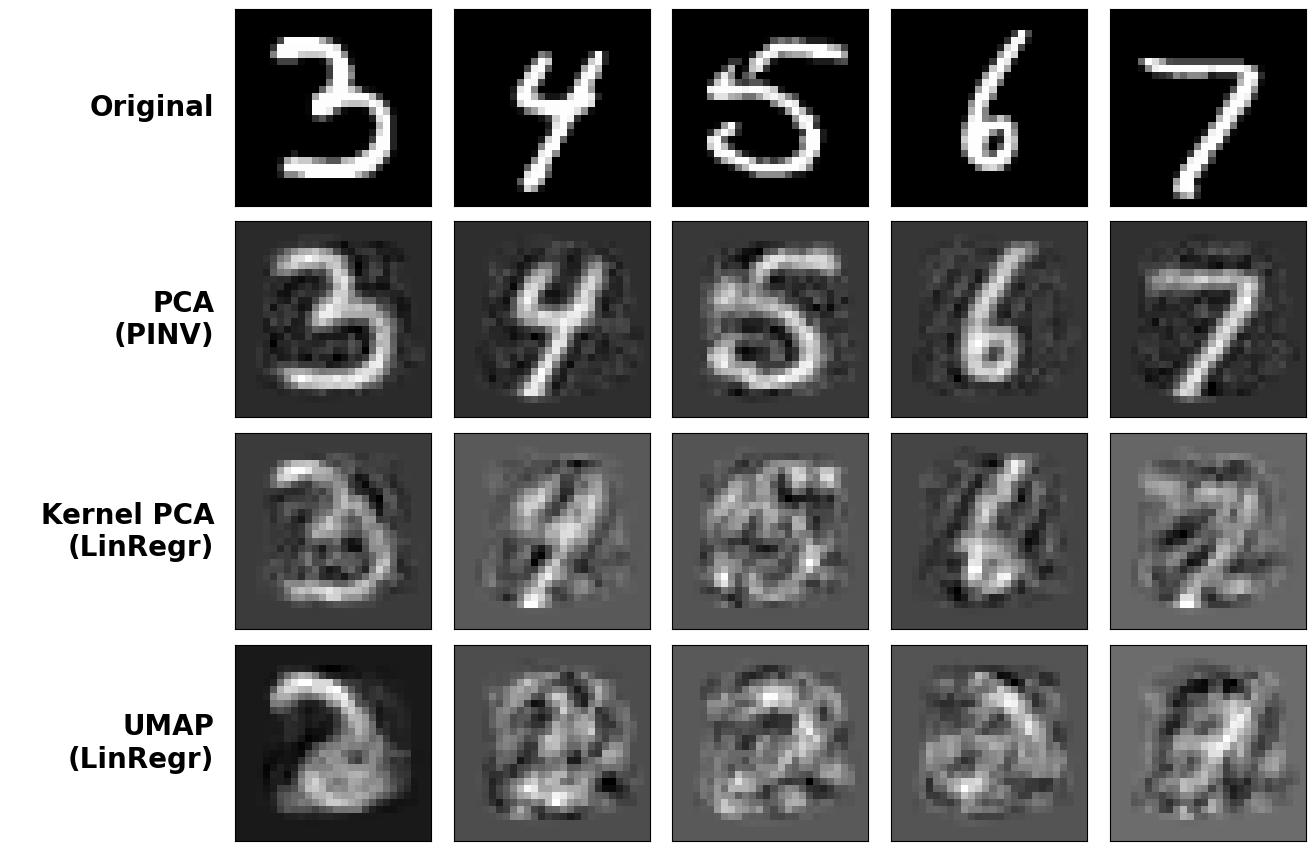

saved: /Users/suetake/git-repos/takano_labo/dca/output/recon/recon_64_4rows_seed101_102_101_104_103.png


In [3]:
import os
import io
import contextlib
import matplotlib.pyplot as plt
from matplotlib import gridspec

from config.config import Config
from src.privacy import run_light_anchor_reconstruction

# ========= base settings (貼ってくれた内容ベース) =========
anchor_labels=(0,1,2)
display_labels = (3, 4, 5, 6, 7)
image_seed_by_label = {3: 101, 4: 102, 5: 101, 6: 104, 7: 103}

common_kwargs = dict(
    anchor_labels=anchor_labels,
    display_labels=display_labels,
    public_per_label=100,
    num_anchor_data=300,
    evaluate_classifier_accuracy=False,
    reconstruct_anchor_images=False,
    image_seed_by_label=image_seed_by_label,
)

base_cfg = dict(
    dataset="mnist",
    y_name="target",
    num_institution_user=1000,
    dim_intermediate=64,
    preprocess=False,
    seed=4,
)

rows = [
    ("Original", None, None),
    ("PCA\n(PINV)", "svd", "PINV"),
    ("Kernel PCA\n(LinRegr)", "kernel_pca_self_tuning", "LinRegr"),
    ("UMAP\n(LinRegr)", "umap", "LinRegr"),
]

def run_quiet(*args, **kwargs):
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        return run_light_anchor_reconstruction(*args, **kwargs)

original_data = None
recon_data = {}

for row_label, f_type, attack in rows:
    if f_type is None:
        continue
    cfg = Config(name=f"recon_{f_type}_d64", F_type=f_type, **base_cfg)
    res = run_quiet(cfg, methods=(attack,), **common_kwargs)

    if original_data is None:
        original_data = {lab: res.selected_images[attack][lab]["original"] for lab in display_labels}
    recon_data[row_label] = {lab: res.selected_images[attack][lab]["reconstructed"] for lab in display_labels}

# ========= plot 4-row grid =========
n_rows = 4
n_cols = len(display_labels)

fig = plt.figure(figsize=(2.8 * (n_cols + 1.0), 2.7 * n_rows))
gs = gridspec.GridSpec(
    n_rows, n_cols + 1,
    width_ratios=[1] + [1] * n_cols,
    wspace=0.05, hspace=0.08
)

row_order = [r[0] for r in rows]
for r, row_name in enumerate(row_order):
    ax_l = fig.add_subplot(gs[r, 0])
    ax_l.axis("off")
    ax_l.text(0.98, 0.5, row_name, ha="right", va="center", fontsize=20, fontweight="bold")

    for c, lab in enumerate(display_labels):
        ax = fig.add_subplot(gs[r, c + 1])
        img = original_data[lab] if r == 0 else recon_data[row_name][lab]
        ax.imshow(img, cmap="gray")
        ax.set_xticks([])
        ax.set_yticks([])

out_dir = "/Users/suetake/git-repos/takano_labo/dca/output/recon"
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "recon_64_4rows_seed101_102_101_104_103.png")

plt.savefig(out_path, dpi=240, bbox_inches="tight")
plt.show()
print("saved:", out_path)
